### Convergence of perceived and real parameters

##### Case for individual targets

**Variable definitions and notation:** Adapted from Tang, et. al. 2024

$\bullet$ $\mu_{ij}(t)$: Trust of agent $i$ towards agent $j$ at time $t$.

$\bullet$ $\gamma_i>1$: Ease of manipulation of agent $i$.

$\bullet$ $f(\mu_{ij}(t), \gamma_i)$: Success probability, s.t. $f(\mu, \gamma)=\frac{\gamma \, \mu}{1+(\gamma - 1)\mu}$.

$\bullet$ $T_{ij}(t)$: Realised trust at interaction $t>0$, s.t. $T_{ij}(t+1)=\begin{cases}1 \text{ with prob. } f(\mu_{ij}(t), \gamma_i)\\ 0 \text{ with prob. } 1-f(\mu_{ij}(t), \gamma_i) \end{cases}$

$\bullet$ Full stochastic dynamics: $\mu_{ij}(t+1) = \frac{t}{t+1}\mu_{ij}(t-1) + \frac{1}{t+1} T_{ij}(t+1)$. For $t>1$ and some initial condition $\mu_{ij}(0)$ (first impression).

NOTE: The estimator $\bar{\mu}_{ij}(t)=\frac{1}{t-1} \sum_{s=2}^{t} T_{ij}$ for $\mu_{ij}(t)$ has an error bounded by $1/t$.

$\bullet$ $\ell_{ij}(\gamma, t)$: Single-step negative log-likelihood given by $\ell_{ij}(\gamma, t)=-[\mathbb{1}\{T_{ij}(t)=1\}log(f(\mu_{ij}(t-1), \gamma))+\mathbb{1}\{T_{ij}(t)=0\}log(1-f(\mu_{ij}(t-1), \gamma))]$

$\bullet$ $\hat{\gamma}(t)$: Online Maximum Likelihood Estimator for $\gamma_i$, given by $\hat{\gamma}(t)=\argmin_{\gamma} \sum_{s=2}^t\ell_{ij}(\gamma, s).$


In [2]:
# Import necessary libraries
import random
import numpy as np

In [3]:
# AUXILIARY FUNCTIONS
def neg_log_likelihood(mu, gamma, T):
    prob = (gamma*mu)/(1+(gamma-1)*mu)
    if T==1:
        if prob == 0:
            return np.inf 
        return -np.log(prob)  
    else:
        if prob == 1:
            return np.inf
        return -np.log(1-prob)

def history_likelihood(history, gamma):
    if len(history) == 0: return "Empty history."

    mu = sum(history[1:])/(len(history) - 1) #TODO: What is a sensible initial value for mu?
    LE = 0  # Likelihood Estimator

    #TODO: Check extreme cases with history [0 0 ...] or [1 1 ...]
          
    for t,T in enumerate(history, start=1):
        LE += neg_log_likelihood(mu, gamma, T)
        mu = (t*mu)/(t+1) + T/(t+1) # Update mu
    return LE

def gamma_MLE(history, gamma_points):
    LES = []  # Likelihood estimators
    m = len(history)

    if m == 0: return "Empty history."

    for gamma in gamma_points:
        LE = history_likelihood(history, gamma) 
        LES.append(LE)

    min_i = np.argmin(LES)
    return gamma_points[min_i]

def expected_mu(history, mu, gamma_points):
    t = len(history)
    
    if t == 0: return "Empty history."

    gamma = gamma_MLE(history, gamma_points)
    prob = (gamma*mu)/(1+(gamma-1)*mu)

    return (t*mu/(t+1)) + (prob/(t+1)), gamma

In [56]:
# Set seeds for reproducibility
# random.seed(10)
# np.random.seed(10)

# DEMO 1: Kipp (K) wants to know how easy it is to manipulate is Filip (F).

# PARAMETERS
t_max = 200
max_gamma = 1 #TODO: Think why the estimator misbehaves when it is greater than 1
num_points = 10
gamma_points = np.linspace(1, 1 + max_gamma, num_points)

# INITIALISE
mu_FK = random.random()                     # Filip's first impression of Kipp
gamma_F = 1 + max_gamma*random.random()     # Filip's bias 
mu_history = [mu_FK]

T0 = np.random.binomial(n=1, p=mu_FK)
history = [T0]                              # History initialised with first observation 
mu_avg_history = []                         # Average estimator of Filip's trust
mu_est_history = []                         # History of expected mu
gamma_est_history = []                      # History of expected gamma

for t in range(2, t_max):
    prob = (gamma_F*mu_FK)/(1+(gamma_F-1)*mu_FK)
    T = np.random.binomial(n=1, p=prob)
    history.append(T)
    
    mu_FK = (t*mu_FK)/(t+1) + T/(t+1)           # Update real trust
    mu_history.append(mu_FK)

    mu_avg = sum(history[1:])/(t-1)             # Average estimator for mu 
    mu_avg_history.append(mu_avg)

    mu_est, gamma = expected_mu(history, mu_avg, gamma_points)
    mu_est_history.append(mu_est)               # Expected mu estimator
    gamma_est_history.append(gamma)             # gamma estimator

print(f"mu error: {np.abs(mu_FK - mu_est)}, expected? {np.abs(mu_FK - mu_est) <= 1/t_max*(t_max-1)}")
print(f"Estimated gamma:{round(gamma, 5)} -vs- Real gamma: {round(gamma_F, 5)} -> error: {np.abs(gamma_F - gamma)}")


mu error: 0.0043821477291918765, expected? True
Estimated gamma:1.33333 -vs- Real gamma: 1.44017 -> error: 0.10683976856550781


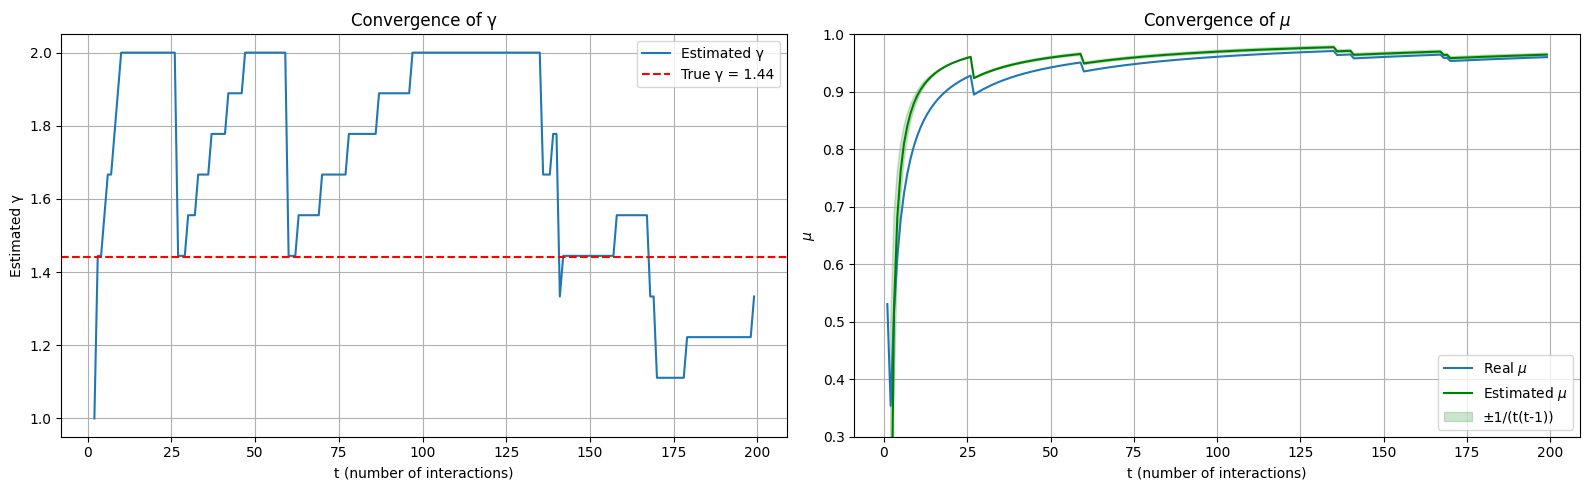

In [57]:
# PLOTTING THE RESULTS
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16,5))  # 1 row, 2 columns

# --- Gamma Estimator ---
axes[0].plot(range(2, t_max), gamma_est_history, label="Estimated γ")
axes[0].axhline(y=gamma_F, color='red', linestyle='--', label=f"True γ = {gamma_F:.2f}")
axes[0].set_xlabel("t (number of interactions)")
axes[0].set_ylabel("Estimated γ")
axes[0].set_title("Convergence of γ")
axes[0].legend()
axes[0].grid(True)

# --- Mu Estimator ---
axes[1].plot(range(1, t_max), mu_history, label="Real $\mu$")
axes[1].plot(range(2, t_max), mu_est_history, label="Estimated $\mu$", color='green')
#axes[1].plot(range(1, t_max), mu_avg_history, label="Average $\mu$", color='orange')

# Compute confidence band
t_vals = np.arange(2, t_max)
conf_band = mu_history[0]/t_max - 1 / (t_vals * (t_vals - 1))
plt.fill_between(t_vals, mu_est_history - conf_band, mu_est_history + conf_band, color='green', alpha=0.2, label="±1/(t(t-1))")

axes[1].set_xlabel("t (number of interactions)")
axes[1].set_ylabel("$\mu$")
axes[1].set_title("Convergence of $\mu$")
axes[1].legend()
axes[1].grid(True)
axes[1].set_ylim(0.3, 1)  # Ensure y-axis is between 0 and 1

plt.tight_layout()
plt.show()


In [ ]:
# DEMO 2: Agent 0 want to estimate the trust of agents in the network

# ----------------------------
# PARAMETERS
# ----------------------------
N = 5                   # Number of agents
t_max = N**2            # Number of interactions   
max_gamma = 1
num_points = 10
gamma_points = np.linspace(1, 1 + max_gamma, num_points)

# ----------------------------
# INITIALISE NETWORK
# ----------------------------
# Real mu and gamma for all agent pairs
mu_real = np.random.rand(N, N)
gamma_real = 1 + max_gamma * np.random.rand(N)

# Skip self-interactions
np.fill_diagonal(mu_real, 0)

# Initialise histories
history = np.zeros((N, N, t_max), dtype=int)       # Interaction outcomes (0-1)
mu_real_history = np.zeros((N, N, t_max))
mu_est_history = np.zeros((N, N, t_max-1))
gamma_est_history = np.zeros((N, t_max-1))

# Initialize first interaction (t=0)
prob_init = (gamma_real * mu_real) / (1 + (gamma_real - 1) * mu_real)
T0 = np.random.binomial(n=1, p=prob_init)
history[:,:,0] = T0
mu_real_history[:,:,0] = mu_real

# ----------------------------
# AUXILIARY FUNCTIONS
# ----------------------------
def neg_log_likelihood(mu, gamma, T):
    prob = (gamma*mu)/(1+(gamma-1)*mu)
    if T==1:
        return np.inf if prob==0 else -np.log(prob)
    else:
        return np.inf if prob==1 else -np.log(1-prob)

def history_likelihood(history_vec, gamma):
    t_len = len(history_vec)
    if t_len == 0: return np.inf
    mu = np.sum(history_vec[1:]) / max(1, (t_len-1))
    LE = 0
    for t, T in enumerate(history_vec, start=1):
        LE += neg_log_likelihood(mu, gamma, T)
        mu = (t*mu)/(t+1) + T/(t+1)
    return LE

def gamma_MLE(history_vec, gamma_points):
    LES = [history_likelihood(history_vec, g) for g in gamma_points]
    return gamma_points[np.argmin(LES)]

def expected_mu(history_vec, mu, gamma_points):
    t = len(history_vec)
    if t == 0: return mu, 1
    gamma = gamma_MLE(history_vec, gamma_points)
    prob = (gamma*mu)/(1+(gamma-1)*mu)
    return (t*mu/(t+1)) + (prob/(t+1)), gamma

# ----------------------------
# SIMULATION LOOP
# ----------------------------
for t in range(1, t_max):
    # Compute probabilities for all pairs
    prob = (gamma_real * mu_real) / (1 + (gamma_real - 1) * mu_real)
    
    # Sample interactions
    T = np.random.binomial(n=1, p=prob)
    history[:,:,t] = T
    
    # Skip self-interactions
    np.fill_diagonal(T, 0)
        
    # Update real mu
    mu_real = (t*mu_real)/(t+1) + T/(t+1)
    mu_real_history[:,:,t] = mu_real
    
    # Compute average mu for estimation
    mu_avg = np.sum(history[:,:,1:t+1], axis=2) / t
    
    # Estimate mu and gamma for all edges
    for i in range(N):
        for j in range(N):
            if i == j: continue
            mu_est, gamma_est = expected_mu(history[i,j,:t+1], mu_avg[i,j], gamma_points)
            mu_est_history[i,j,t-1] = mu_est
            gamma_est_history[i,t-1] = gamma_est


In [100]:
print(mu_real[:,0])
print(gamma_real)

[0.         0.97767082 0.93239259 0.01524541 0.86058039]
[1.14769635 1.2312279  1.27882844 1.79684001 1.67621982]


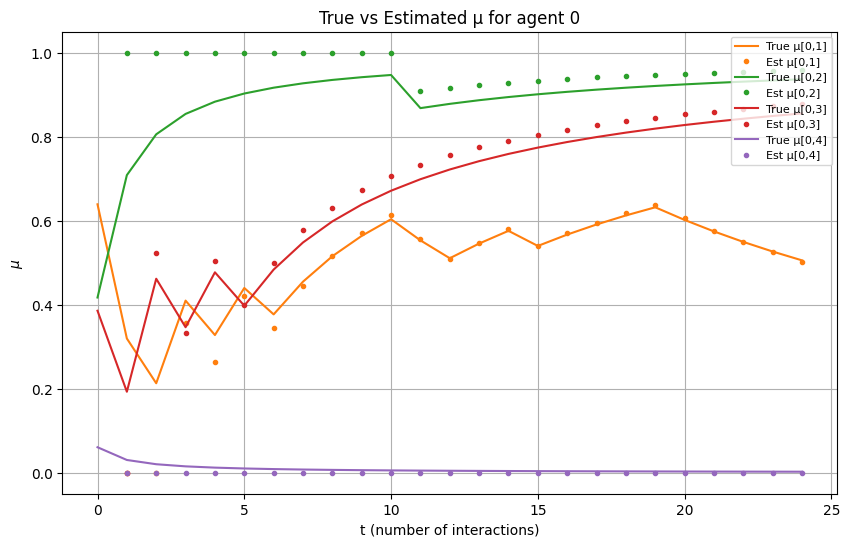

In [101]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

agent_id = 0  # choose the agent
t_vals = np.arange(t_max)

plt.figure(figsize=(10,6))

# Choose a colormap
colors = cm.tab10.colors  # Up to 10 distinct colors

for j in range(N):
    if j == agent_id:
        continue
    color = colors[j % 10]  # cycle through colors if N>10

    # True μ as solid line
    true_mu = mu_real_history[agent_id,j,:]
    plt.plot(t_vals, true_mu, linestyle='-', color=color, label=f"True μ[{agent_id},{j}]")

    # Estimated μ as same color with markers
    est_mu = mu_est_history[agent_id,j,:]
    plt.plot(t_vals[1:], est_mu, linestyle='None', marker='o', markersize=3, color=color, label=f"Est μ[{agent_id},{j}]")

plt.xlabel("t (number of interactions)")
plt.ylabel("$\mu$")
plt.title(f"True vs Estimated μ for agent {agent_id}")
plt.legend(loc='upper right', fontsize=8)
plt.grid(True)
plt.show()

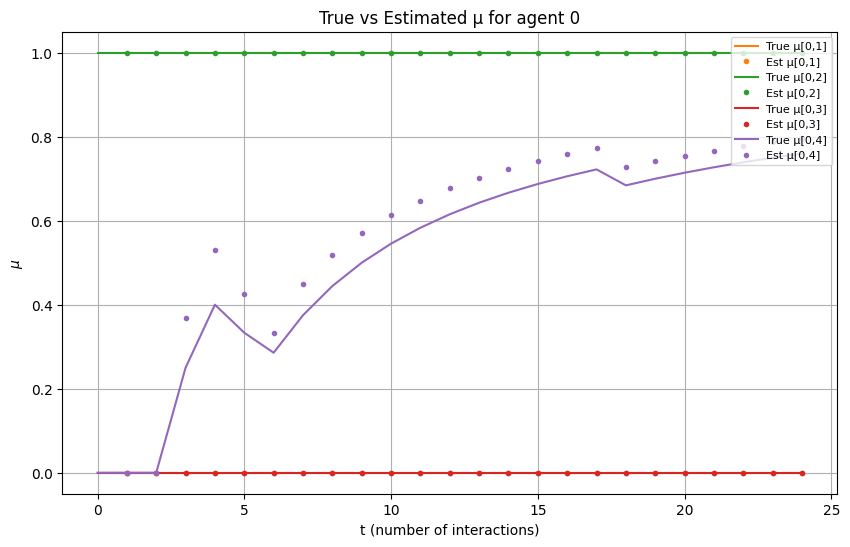

In [84]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

agent_id = 0  # choose the agent
t_vals = np.arange(t_max)

plt.figure(figsize=(10,6))

# Choose a colormap
colors = cm.tab10.colors  # Up to 10 distinct colors

for j in range(N):
    if j == agent_id:
        continue
    color = colors[j % 10]  # cycle through colors if N>10

    # True μ as solid line
    true_mu = history[agent_id,j,:].cumsum()/(np.arange(t_max)+1)
    plt.plot(t_vals, true_mu, linestyle='-', color=color, label=f"True μ[{agent_id},{j}]")

    # Estimated μ as same color with markers
    est_mu = mu_est_history[agent_id,j,:]
    plt.plot(t_vals[1:], est_mu, linestyle='None', marker='o', markersize=3, color=color, label=f"Est μ[{agent_id},{j}]")

plt.xlabel("t (number of interactions)")
plt.ylabel("$\mu$")
plt.title(f"True vs Estimated μ for agent {agent_id}")
plt.legend(loc='upper right', fontsize=8)
plt.grid(True)
plt.show()


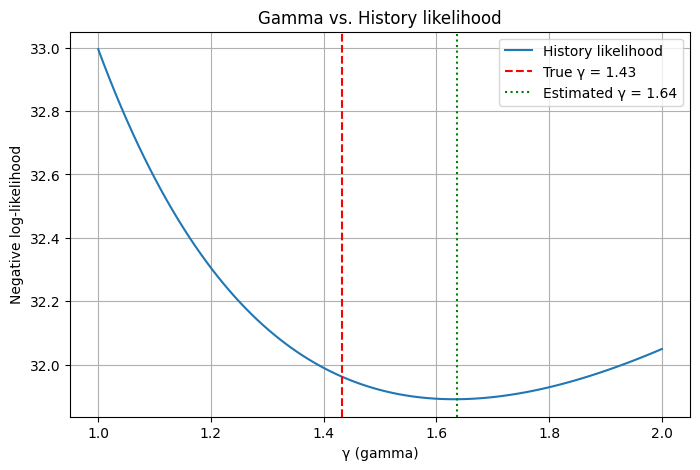

In [ ]:

# Compute likelihoods for all gamma_points
LES = [history_likelihood(history, gamma) for gamma in gamma_points]

# Make the plot
plt.figure(figsize=(8,5))
plt.plot(gamma_points, LES, label="History likelihood")

# Mark the true gamma
plt.axvline(x=gamma_F, color='red', linestyle='--', label=f"True γ = {gamma_F:.2f}")

# Mark the estimated gamma
plt.axvline(x=gamma_points[np.argmin(LES)], color='green', linestyle=':', label=f"Estimated γ = {gamma_MLE:.2f}")

plt.xlabel("γ (gamma)")
plt.ylabel("Negative log-likelihood")
plt.title(f"Gamma vs. History likelihood")
plt.legend()
plt.grid(True)
plt.show()